In [1]:
import numpy as np
from asrl.ogmapping.ogmapper import OccupancyGridMapper
import matplotlib.pyplot as plt
from time import perf_counter

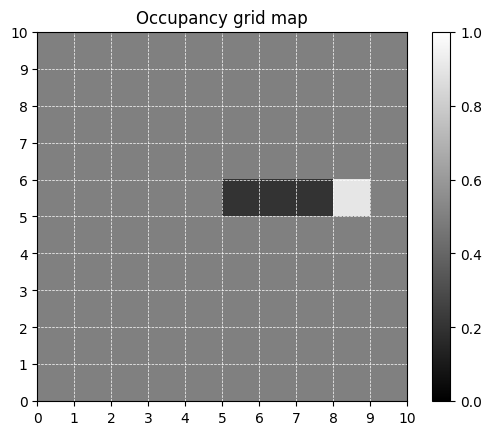

In [2]:
og_mapper = OccupancyGridMapper(resolution=1.0, width_m=10, height_m=10,
                                p_hit=0.9, p_miss=0.2)

simple_points = np.array([[3.2, 0.0]])
pose = np.array([5.5, 5.5, 0.0])

og_mapper.process_scan(pose, simple_points)
grid_prob = og_mapper.log_odds_map_to_prob_map()

res = og_mapper.resolution
width_cells = og_mapper.grid.shape[1]
height_cells = og_mapper.grid.shape[0]
extent = [0, width_cells * res, 0, height_cells * res]

plt.figure()
plt.imshow(grid_prob, vmin=0, vmax=1,cmap='gray', interpolation='nearest',
           origin='upper', extent=extent)
xticks = np.arange(0, width_cells * res + 0.1, 1.0)
yticks = np.arange(0, height_cells * res + 0.1, 1.0)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar()
plt.title('Occupancy grid map')
plt.show()

og_mapper.reset_grid()

In [19]:
og_mapper = OccupancyGridMapper(resolution=0.5, width_m=100, height_m=100,
                                p_hit=0.9, p_miss=0.2)

pose = np.array([5, 5, 0])
angles = np.linspace(0, 2*np.pi, 360, endpoint=False)
radii = 1.0 + 2.0 * np.cumsum(np.ones_like(angles)) / len(angles)

cos_theta, sin_theta = np.cos(angles), np.sin(angles)
xs = radii * cos_theta
ys = radii * sin_theta
points = np.stack((xs, ys), axis=-1)

# Do a quick time test
n_trials = 100
total_time = 0.0
for _ in range(n_trials):
    # points = points.repeat(500, axis=0)
    start = perf_counter()
    og_mapper.process_scan(pose, points)
    total_time += perf_counter() - start
    
    og_mapper.reset_grid()

print(f"Avg. time per scan: {1e3 * total_time / n_trials :.6f} ms")

# og_mapper.process_scan(pose, points)
# grid_prob = og_mapper.log_odds_map_to_prob_map()

# res = og_mapper.resolution
# width_cells = og_mapper.grid.shape[1]
# height_cells = og_mapper.grid.shape[0]
# extent = [0, width_cells * res, 0, height_cells * res]

# plt.figure()
# plt.imshow(grid_prob, vmin=0, vmax=1,cmap='gray', interpolation='nearest',
#            origin='upper', extent=extent)

# points_world = points + pose[:2]
# plt.scatter(points_world[:, 0], points_world[:, 1], c='red', s=1, label='Scan')

# xticks = np.arange(0, width_cells * res + 0.1, 1.0)
# yticks = np.arange(0, height_cells * res + 0.1, 1.0)
# plt.xticks(xticks)
# plt.yticks(yticks)

# plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
# plt.colorbar()
# plt.legend()
# plt.title('Occupancy grid map')
# plt.show()

# og_mapper.reset_grid()

Avg. time per scan: 0.282449 ms


In [4]:
og_mapper = OccupancyGridMapper(resolution=0.1, width_m=10, height_m=10,
                                p_hit=0.9, p_miss=0.2)

og_mapper.reset_grid()

n_trials = 1000
total_time = 0.0
for _ in range(n_trials):
    start = perf_counter()
    og_mapper.process_scan(pose, points)
    total_time += perf_counter() - start
    
    og_mapper.reset_grid()

print(f"Avg. time per scan: {1e3 * total_time / n_trials :.6f} ms")

Avg. time per scan: 0.688717 ms
